# Monotone function examples
In this notebook we shall:
- Simulate an ad marketplace: auctions of several buyers competing for opportunities from several sellers
- Collect a log of (auction features, bid, win=0/1) of auction features, our bid, and us winning or losing the auction
- Train a neural network using B-Spline curves to model probability of winning as an **increasing** function of the bid
- Plot several such learned functions

## Imports

In [1]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import scipy.special
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange

import torchcurves as tc


## Simulate auctions

In [2]:
@dataclass
class Seller:
    """Sellers have feature vectors, and draw auction features in the vicinity of those vectors."""

    features: np.typing.NDArray
    std: float

    @classmethod
    def draw_seller(cls, dim: int, rng: np.random.Generator):
        return cls(
            features=rng.standard_normal(size=dim),
            std=0.5 / math.sqrt(dim),
        )

    def draw_auction_features(self) -> np.typing.NDArray:
        return self.features + self.std * rng.standard_normal(len(self.features))

@dataclass
class Buyer:
    """Buyers have preference features, and bid higher the closer are their own preferences to auction features."""

    daily_budget: float
    budget: float
    preferences: np.typing.NDArray

    @classmethod
    def draw_player(cls, mean_budget: float, dim: int, rng: np.random.Generator):
        daily_budget = rng.exponential(scale=mean_budget)
        return cls(
            daily_budget=daily_budget,
            budget=daily_budget,
            preferences=rng.normal(size=dim),
        )

    def reset_budget(self):
        self.budget = self.daily_budget

    def bid(self, auction_features: np.typing.NDArray):
        # bid inversely proportional to the distance from preferences to features
        dist = np.linalg.norm(self.preferences - auction_features, 1)
        desired_bid = np.reciprocal(dist)
        return min(self.budget, desired_bid)

    def charge(self, amount: float):
        self.budget -= amount

In [3]:
n_buyers = 15     # we and (n_buyers - 1) competitors
n_sellers = 10

feature_dim = 3
n_daily_auctions = 2000
n_days = 5
mean_buyer_budget = n_daily_auctions / n_buyers
rng = np.random.default_rng(42)

In [4]:
buyers = [Buyer.draw_player(mean_buyer_budget, feature_dim, rng) for _ in range(n_buyers)]
sellers = [Seller.draw_seller(feature_dim, rng) for _ in range(n_sellers)]

player_prefs = np.vstack([player.preferences for player in buyers])
seller_weights = scipy.special.softmax(rng.uniform(size=n_sellers))

# a list to store the features of each auction
auction_feature_log = []
budget_fraction_log = []

# lists to store auction results
our_idx = 0   # we are the first buyer
our_bids = []
our_wins = []

for _day in trange(n_days, leave=True):
    for _i in trange(n_daily_auctions, leave=False):
        # draw a seller and let the them choose auction features
        seller = sellers[rng.choice(n_sellers, p=seller_weights)]
        current_auction_features = seller.draw_auction_features()

        # budgets submit bids
        bids = np.asarray([player.bid(current_auction_features) for player in buyers])
        our_bid = bids[our_idx]

        # store features and bids
        auction_feature_log.append(current_auction_features)
        budget_fraction_log.append(buyers[our_idx].budget / buyers[our_idx].daily_budget)
        our_bids.append(our_bid)

        # determine and charge the winner, and log if we won
        has_winner = np.any(bids > 0)
        if has_winner:
            winner_idx = np.argmax(bids).item()
            buyers[winner_idx].charge(bids[winner_idx])
            our_wins.append(1. if winner_idx == our_idx else 0.)
        else:
            our_wins.append(0.)

    for buyer in buyers:
        buyer.reset_budget()

auction_feature_log = np.vstack(auction_feature_log)
budget_fraction_log = np.asarray(budget_fraction_log)
our_bids = np.asarray(our_bids)
our_wins = np.asarray(our_wins)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

## Prepare train / validation data

In [5]:
def to_torch(mask, *arrays):
    tensors = (
        torch.as_tensor(t[mask], dtype=torch.get_default_dtype())
        for t in arrays
    )
    return TensorDataset(*tensors)

In [6]:
# features include budget fractions
X = np.hstack((auction_feature_log, budget_fraction_log.reshape(-1, 1)))

In [7]:
train_frac = 0.8
train_mask = rng.random(size=X.shape[0]) < train_frac
train_ds = to_torch(train_mask, X, our_bids, our_wins)
val_ds = to_torch(~train_mask, X, our_bids, our_wins)

## Define the model

In [8]:
def make_mlp(input_dim: int, output_dim: int):
    num_hidden_layers = 10
    hidden_dim = 8 * max(input_dim, output_dim)
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        *( # Repeated linear + relu layers
            layer
            for _ in range(num_hidden_layers)
            for layer in [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        ),
        nn.Linear(hidden_dim, output_dim),
    )

In [9]:
class BidModel(nn.Module):
    def __init__(self, input_dim: int, num_coefficients: int):
        super().__init__()
        self.coef_model = make_mlp(input_dim, num_coefficients)
        self.bid_basis = tc.BSplineBasis(
            degree=3,
            knots_config=num_coefficients,
            parameter_range=(0, 1),
            input_map=tc.maps.Nonneg.rational(),
        )

    def forward(self, auction_features: torch.Tensor, bid: torch.Tensor) -> torch.Tensor:
        # map auction features to increasing spline coefficients via MLP + increasing transform
        coefficients = self.coef_model(auction_features)
        increasing_coefficients = self._make_increasing(coefficients)

        # compute a B-Spline function that by-design increases with the bid!
        # B x C x 1 (B curves with C coefficients in 1 dimension)
        increasing_coefficients = increasing_coefficients.unsqueeze(-1)
        # 1 x B (B curves in 1 dimension)
        bid = bid.unsqueeze(0)
        return self.bid_basis(bid, increasing_coefficients).squeeze(0).squeeze(-1)

    @staticmethod
    def _make_increasing(x):
        initial = x[..., :1]
        increments = nn.functional.softplus(x[..., 1:])
        concatenated = torch.concat((initial, increments), dim=-1)
        return torch.cumsum(concatenated, dim=-1)

In [10]:
# model params
num_coefficients = 20

# training params
num_epochs = 10
batch_size = 64
lr = 1e-4

# create model, loss, optimizer, and dataloaders
model = BidModel(X.shape[1], num_coefficients)
loss = nn.BCEWithLogitsLoss()
opt = optim.AdamW(model.parameters(), lr=lr)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=len(val_ds))

# training loop
for epoch in range(1, 1 + num_epochs):
    epoch_loss = torch.tensor(0.)
    for X_batch, bid_batch, win_batch in train_dl:
        opt.zero_grad()
        y_pred = model(X_batch, bid_batch)
        loss_val = loss(y_pred, win_batch)
        loss_val.backward()
        opt.step()

        with torch.no_grad():
            epoch_loss += loss_val * len(X_batch)
    epoch_loss /= len(train_ds)

    with torch.no_grad():
        for X_batch, bid_batch, win_batch in val_dl:
            y_pred = model(X_batch, bid_batch)
            valid_loss = loss(y_pred, win_batch)

    print(f'Epoch = {epoch}, Loss = {epoch_loss:.4f}, Valid Loss = {valid_loss:.4f}')

Epoch = 1, Loss = 2.4027, Valid Loss = 0.4642
Epoch = 2, Loss = 0.3620, Valid Loss = 0.3047
Epoch = 3, Loss = 0.2425, Valid Loss = 0.2022
Epoch = 4, Loss = 0.1832, Valid Loss = 0.1634
Epoch = 5, Loss = 0.1647, Valid Loss = 0.1538
Epoch = 6, Loss = 0.1581, Valid Loss = 0.1544
Epoch = 7, Loss = 0.1460, Valid Loss = 0.1540
Epoch = 8, Loss = 0.1432, Valid Loss = 0.1392
Epoch = 9, Loss = 0.1361, Valid Loss = 0.1297
Epoch = 10, Loss = 0.1335, Valid Loss = 0.1290


## Plot  f(bid) = P(win | auction, bid) for several auctions from the validation set

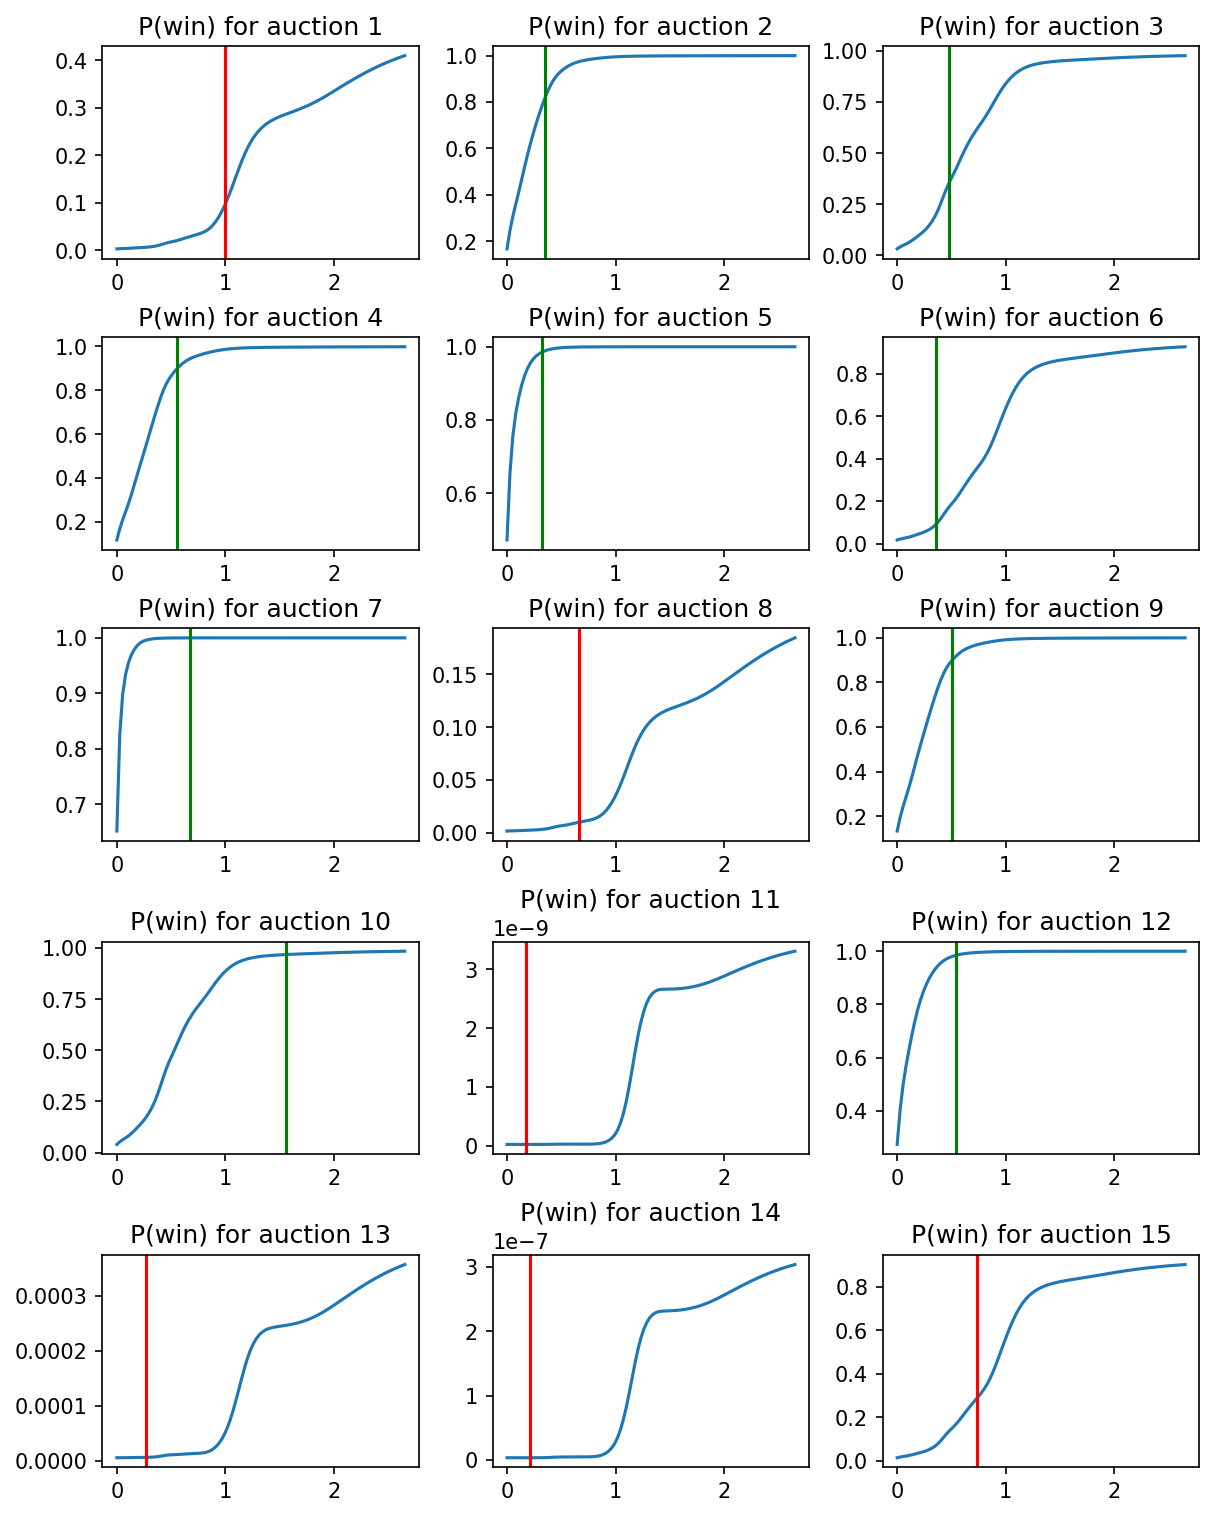

In [11]:
num_plots = 15
num_plot_cols = 3
num_plot_rows = 5
plot_resolution = 100

fig, axs = plt.subplots(
    num_plot_rows, num_plot_cols,
    figsize=(2.66 * num_plot_cols, 2 * num_plot_rows),
    dpi=150,
    layout='constrained',)

max_bid = np.max(our_bids).item()
plot_bids = torch.linspace(0, max_bid, plot_resolution)

auctions_to_plot = rng.choice(len(val_ds), num_plots, replace=False).tolist()
selected_feats, selected_bids, selected_wins = val_ds[auctions_to_plot]

for i, (ax, feats, bid, win) in enumerate(zip(axs.ravel(), selected_feats, selected_bids, selected_wins), start=1):
    with torch.no_grad():
        pred_logits = model(feats.expand(plot_resolution, -1), plot_bids)
        pred_probs = torch.sigmoid(pred_logits)
        mlp_output = model.coef_model(feats)

    ax.plot(plot_bids, pred_probs)
    ax.axvline(bid, color=('green' if win else 'red'))
    ax.set_title(f'P(win) for auction {i}')